### Importing Libraries / Tools / Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

### Data Preprocessing 1 : Cleaning

In [2]:
# 1. Drop the ID (useless for finding patterns, causes overfitting)
df.drop('customerID', axis=1, inplace=True)

# 2. Fix the "Stupid" Value: Convert TotalCharges to numeric, force blanks to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Handle NaNs: Only 11 rows are missing TotalCharges. Safe to drop them.
df.dropna(inplace=True)

# 4. Check for duplicates (None expected, but good practice)
print(f"Duplicates found: {df.duplicated().sum()}")

# 5. Convert the Target Variable to binary immediately so we can do correlation
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

Duplicates found: 22


### Data Preprocessing 2 : Correlation Analysis

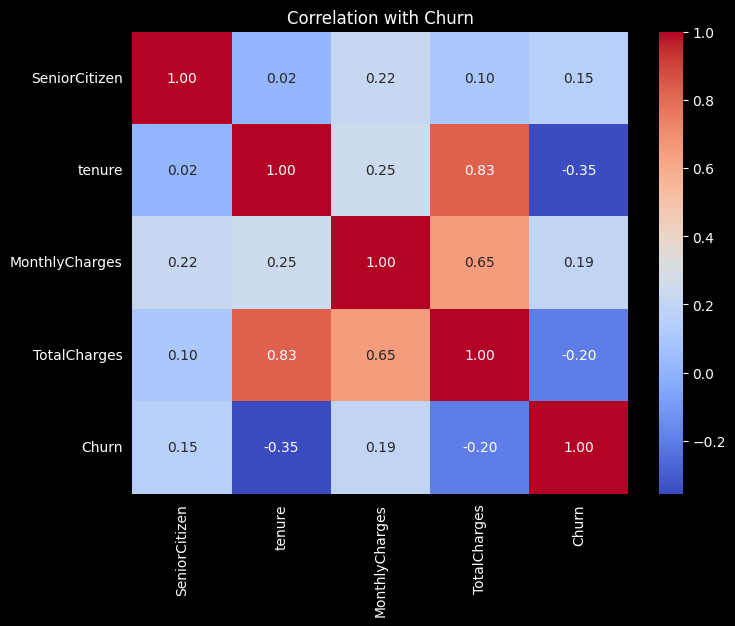

In [3]:
# We isolate only the numeric columns to check their mathematical relationship to Churn
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation with Churn")
plt.show()

# Insight: 'tenure' has a strong negative correlation (-0.35). The longer they stay, the less likely they are to churn.
# 'MonthlyCharges' has a positive correlation (0.19). Higher bills = more churn.

### Data Preprocessing 3 : Train-Test Split

In [4]:
X = df.drop('Churn', axis=1) # Everything except the target
y = df['Churn']              # Only the target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (5625, 19)
Testing data shape: (1407, 19)


### Data Preprocessing 4 : Encoding (One-Hot) & Scaling Pipeline

In [5]:
# Define which columns are which
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [col for col in X_train.columns if col not in numerical_cols]

# Create the preprocessor engine
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols), # Step IV: Scaling
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols) # Step III: OHE
    ])

# Fit it ONLY on the training data, then transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing complete. Data is scaled and encoded.")

Preprocessing complete. Data is scaled and encoded.


### STEP-5 : Training a Selected Model (xGBoost)

In [6]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import pickle

# 1. Combine the preprocessor and algorithm into ONE Pipeline
# This ensures that any new data fed into the model later gets scaled and encoded automatically!
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
])

# 2. Train the Pipeline
# (Notice we pass the RAW X_train, not the processed version. The pipeline handles the translation!)
pipeline.fit(X_train, y_train)

# 3. Evaluate the Model (Testing it on the 20% unseen data)
accuracy = pipeline.score(X_test, y_test)
print(f"Model Accuracy on Unseen (Test) Data: {accuracy:.2%}")

# 4. EXPORT: Save the trained 'Model' to your hard drive
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

print("SUCCESS: 'churn_model.pkl' created. Phase 1 complete!")

Model Accuracy on Unseen (Test) Data: 79.10%
SUCCESS: 'churn_model.pkl' created. Phase 1 complete!


### STEP-6 : Model Evaluation by Accuracy

In [7]:
train_acc = pipeline.score(X_train, y_train)
test_acc = pipeline.score(X_test, y_test)
print(f"Training Accuracy: {train_acc:.2%}")
print(f"Testing Accuracy: {test_acc:.2%}")

# This is a bit overfitting, but good enough.

Training Accuracy: 86.74%
Testing Accuracy: 79.10%


### STEP-7 : Hyperparameter Tuning to reduce Overfit (by using Random Search)

In [8]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Define the "Grid" of settings to test
# Notice the "classifier__" prefix. We have to tell the Pipeline which step we are tuning!
param_distributions = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 4, 5],           # Restricting depth prevents memorization
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__subsample': [0.6, 0.8, 1.0],     # Training on fractions of data to add randomness
}

# 2. Set up the Random Search
# n_iter=10 means it will randomly pick 10 combinations from the grid above to test.
# cv=3 means 3-fold cross-validation (it tests each combo 3 times on different data slices).
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    scoring='accuracy',
    cv=3,
    random_state=42,
    n_jobs=-1 # Uses all your CPU cores to speed it up!
)

# 3. RUN THE SEARCH (This might take 60-90 seconds)
print("Tuning hyperparameters... please wait.")
random_search.fit(X_train, y_train)

# 4. Get the Results
best_model = random_search.best_estimator_
print(f"\nBest Parameters Found: {random_search.best_params_}")

# 5. Evaluate the newly tuned model
train_acc_tuned = best_model.score(X_train, y_train)
test_acc_tuned = best_model.score(X_test, y_test)

print(f"\nTuned Training Accuracy: {train_acc_tuned:.2%}")
print(f"Tuned Testing Accuracy: {test_acc_tuned:.2%}")
print(f"New Gap: {train_acc_tuned - test_acc_tuned:.2%}")

# 6. EXPORT THE CHAMPION
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("\nSUCCESS: The optimized model has been pickled!")

Tuning hyperparameters... please wait.

Best Parameters Found: {'classifier__subsample': 0.6, 'classifier__n_estimators': 100, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05}

Tuned Training Accuracy: 81.33%
Tuned Testing Accuracy: 79.10%
New Gap: 2.23%

SUCCESS: The optimized model has been pickled!
